# ConvNeXt-Tiny

- Предобученная модель (timm), 4 класса застройки
- Этап 1: обучение головы, подбор LR
- Этап 2: постепенная разморозка слоёв, LR ниже
- Ранняя остановка, графики, матрица ошибок, примеры

Split: `data/processed/split.csv` (как в `02_baseline.ipynb`).

In [1]:
import copy
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from dataset import BuildingDataset, CLASSES, get_train_transforms, get_transforms, load_split
from model_convnext import build_convnext_tiny, unfreeze_all, unfreeze_stages, count_trainable_params

# параметры
RANDOM_SEED = 42
SPLIT_CSV = PROJECT_ROOT / 'data' / 'processed' / 'split.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
REPORTS_DIR = PROJECT_ROOT / 'reports'

BATCH_SIZE = 32
MAX_EPOCHS = 100
LOSS_EPS = 1e-4
PATIENCE = 7
MIN_EPOCHS = 25

LR_CANDIDATES = [1e-3, 1e-4, 1e-5]
STAGE1_MAX_EPOCHS = 15
STAGE1_MIN_EPOCHS = 5
STAGE1_PATIENCE = 5

# этап 2: (сколько блоков разморозить, во сколько раз уменьшить LR)
STAGE2_STEPS = [(2, 10), (4, 20), (4, 50)]

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)
if torch.cuda.is_available():
    print('ГПУ:', torch.cuda.get_device_name(0))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Устройство: cuda
ГПУ: NVIDIA GeForce RTX 4060 Laptop GPU


## Данные

`split.csv` — те же train / val / test, что в baseline.

In [2]:
if not SPLIT_CSV.exists():
    raise FileNotFoundError(
        f'{SPLIT_CSV} не найден. Split создаётся в 02_baseline.ipynb.'
    )

split_df = load_split(SPLIT_CSV)
print('Размеры выборок:')
_split_ru = {'train': 'обучение', 'val': 'валидация', 'test': 'тест'}
_split_counts = split_df['split'].value_counts().reindex(['train', 'val', 'test'])
_split_counts.index = [_split_ru[k] for k in _split_counts.index]
print(_split_counts)
print()
print('Источники данных:')
print(split_df['source'].value_counts())

Размеры выборок:
обучение     2197
валидация     471
тест          471
Name: count, dtype: int64

Источники данных:
source
NWPU-RESISC45    1696
AID              1443
Name: count, dtype: int64


## DataLoader

In [3]:
eval_transform = get_transforms(image_size=224)
train_transform = get_train_transforms(image_size=224, augment=False)

train_ds = BuildingDataset(split_df, split='train', classes=CLASSES, transform=train_transform)
val_ds = BuildingDataset(split_df, split='val', classes=CLASSES, transform=eval_transform)
test_ds = BuildingDataset(split_df, split='test', classes=CLASSES, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Обучение: {len(train_ds)} | Валидация: {len(val_ds)} | Тест: {len(test_ds)}')

Обучение: 2197 | Валидация: 471 | Тест: 471


## Одна эпоха

In [ ]:
def run_epoch(loader, model, criterion, optimizer=None):
    """Одна эпоха: обучение или оценка."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy, macro_f1


@torch.no_grad()
def collect_predictions(loader, model):
    """Предсказания модели на выборке."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().tolist())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


def _loss_plateau(val_losses, eps=LOSS_EPS, patience=PATIENCE):
    """Loss на val почти не меняется несколько эпох подряд."""
    if len(val_losses) < patience + 1:
        return False
    recent = val_losses[-patience:]
    return all(abs(recent[i] - recent[i - 1]) < eps for i in range(1, len(recent)))


def train_loop(model, train_loader, val_loader, lr, max_epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS,
               loss_eps=LOSS_EPS, patience=PATIENCE, weight_decay=1e-4, label='', verbose=True):
    """Цикл обучения с ранней остановкой."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_f1', 'lr']}
    best_val_f1, best_epoch = -1.0, 0
    best_state = copy.deepcopy(model.state_dict())
    prefix = f'[{label}] ' if label else ''

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        train_loss, train_acc, _ = run_epoch(train_loader, model, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(val_loader, model, criterion, optimizer=None)
        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(lr_now)

        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            marker = ' <- лучшая' if is_best else ''
            print(
                f'{prefix}Эпоха {epoch:3d}/{max_epochs} | '
                f'потери_обуч={train_loss:.4f} точн_обуч={train_acc:.4f} | '
                f'потери_пров={val_loss:.4f} точн_пров={val_acc:.4f} macro F1={val_f1:.4f} | '
                f'{time.time() - t0:.1f}s{marker}'
            )

        if epoch >= min_epochs and _loss_plateau(history['val_loss'], loss_eps, patience):
            if verbose:
                print(f'{prefix}Ранняя остановка')
            break

    return {
        'history': history,
        'best_f1': best_val_f1,
        'best_acc': history['val_acc'][best_epoch - 1],
        'best_epoch': best_epoch,
        'best_state': best_state,
        'epochs_run': len(history['train_loss']),
    }


def print_classification_report_ru(y_true, y_pred, target_names):
    """Отчёт по классам."""
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0)
    print(f"{'класс':<22} {'прециз.':>8} {'полнота':>8} {'F1':>8} {'объектов':>8}")
    for name in target_names:
        r = report[name]
        print(f"{name:<22} {r['precision']:8.2f} {r['recall']:8.2f} {r['f1-score']:8.2f} {int(r['support']):8d}")
    n = int(report['macro avg']['support'])
    print(f"{'точность':<22} {report['accuracy']:8.2f} {'':>8} {'':>8} {n:8d}")
    m = report['macro avg']
    print(f"{'среднее macro':<22} {m['precision']:8.2f} {m['recall']:8.2f} {m['f1-score']:8.2f} {n:8d}")
    w = report['weighted avg']
    print(f"{'среднее взвеш.':<22} {w['precision']:8.2f} {w['recall']:8.2f} {w['f1-score']:8.2f} {n:8d}")


## Этап 1: подбор LR

Кандидаты: `1e-3`, `1e-4`, `1e-5`. Заморожена основа, обучается только голова.

In [5]:
criterion = nn.CrossEntropyLoss()

lr_search_results = {}
stage1_best_state = None
stage1_best_f1 = -1.0
best_lr = None

for lr in LR_CANDIDATES:
    torch.manual_seed(RANDOM_SEED)
    model = build_convnext_tiny(num_classes=len(CLASSES), freeze_backbone=True).to(device)
    print(f'\n--- LR={lr:.0e} | обучаемых параметров: {count_trainable_params(model):,} ---')

    result = train_loop(
        model, train_loader, val_loader, lr,
        max_epochs=STAGE1_MAX_EPOCHS,
        min_epochs=STAGE1_MIN_EPOCHS,
        patience=STAGE1_PATIENCE,
        label=f'этап1_{lr:.0e}',
    )

    lr_search_results[lr] = {
        'best_val_f1': result['best_f1'],
        'best_val_acc': result['best_acc'],
        'epochs_run': result['epochs_run'],
        'history': result['history'],
    }

    if result['best_f1'] > stage1_best_f1:
        stage1_best_f1 = result['best_f1']
        stage1_best_state = result['best_state']
        best_lr = lr

print(f'\nЛучший LR для этапа 1: {best_lr:.0e} (macro F1={stage1_best_f1:.4f})')


--- LR=1e-03 | обучаемых параметров: 4,612 ---
[этап1_1e-03] Эпоха   1/15 | потери_обуч=0.4646 точн_обуч=0.8298 | потери_пров=0.2364 точн_пров=0.9321 macro F1=0.9335 | 20.0s <- лучшая
[этап1_1e-03] Эпоха   2/15 | потери_обуч=0.1761 точн_обуч=0.9508 | потери_пров=0.1695 точн_пров=0.9554 macro F1=0.9560 | 17.7s <- лучшая
[этап1_1e-03] Эпоха   3/15 | потери_обуч=0.1252 точн_обуч=0.9677 | потери_пров=0.1388 точн_пров=0.9597 macro F1=0.9601 | 21.6s <- лучшая
[этап1_1e-03] Эпоха   4/15 | потери_обуч=0.0982 точн_обуч=0.9777 | потери_пров=0.1193 точн_пров=0.9703 macro F1=0.9707 | 23.0s <- лучшая
[этап1_1e-03] Эпоха   5/15 | потери_обуч=0.0782 точн_обуч=0.9827 | потери_пров=0.1116 точн_пров=0.9639 macro F1=0.9643 | 23.7s
[этап1_1e-03] Эпоха   6/15 | потери_обуч=0.0669 точн_обуч=0.9873 | потери_пров=0.1086 точн_пров=0.9703 macro F1=0.9708 | 23.3s <- лучшая
[этап1_1e-03] Эпоха   7/15 | потери_обуч=0.0593 точн_обуч=0.9882 | потери_пров=0.1003 точн_пров=0.9703 macro F1=0.9708 | 24.8s <- лучшая
[эт

In [6]:
lr_summary = pd.DataFrame([
    {
        'LR': lr,
        'macro F1': res['best_val_f1'],
        'точность': res['best_val_acc'],
        'эпох': res['epochs_run'],
    }
    for lr, res in lr_search_results.items()
])
print(lr_summary)

   скорость обучения  macro F1 на валидации  точность на валидации  эпох
0             0.0010               0.972826               0.972399    15
1             0.0003               0.968535               0.968153    15
2             0.0001               0.954174               0.953291    15


## Этап 2: дообучение

Старт с лучших весов этапа 1. Три шага — размораживается больше слоёв, LR ниже:

1. 2 последних блока — `best_lr / 10`
2. все 4 блока — `best_lr / 20`
3. вся сеть — `best_lr / 50`

На каждом шаге — ранняя остановка. Лучшая модель — по macro F1 на val.

In [7]:
def run_progressive_finetune(train_loader):
    """Три подэтапа с разморозкой блоков."""
    substage_results = []
    best_substage = None
    combined_history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_f1', 'lr']}
    best_f1, best_acc, best_state = -1.0, 0.0, None
    remaining_epochs = MAX_EPOCHS

    for step_idx, (n_stages, lr_divisor) in enumerate(STAGE2_STEPS):
        if remaining_epochs <= 0:
            break

        torch.manual_seed(RANDOM_SEED)
        model = build_convnext_tiny(num_classes=len(CLASSES), freeze_backbone=True).to(device)
        model.load_state_dict(stage1_best_state)

        if step_idx == len(STAGE2_STEPS) - 1:
            unfreeze_all(model)
            stage_label = 'вся сеть'
        else:
            unfreeze_stages(model, n_stages)
            stage_label = f'последние {n_stages} стадии'

        fine_tune_lr = best_lr / lr_divisor
        print(
            f'\n--- Подэтап {step_idx + 1}/{len(STAGE2_STEPS)}: {stage_label} | '
            f'LR={fine_tune_lr:.1e} | обучаемых параметров: {count_trainable_params(model):,} ---'
        )

        result = train_loop(
            model, train_loader, val_loader, fine_tune_lr,
            max_epochs=remaining_epochs,
            min_epochs=max(5, MIN_EPOCHS // 3),
            label=f'этап2_{step_idx + 1}',
        )

        for key in combined_history:
            combined_history[key].extend(result['history'][key])

        substage_results.append({
            'substage': step_idx + 1,
            'epochs_run': result['epochs_run'],
            'best_f1': result['best_f1'],
            'best_epoch': result['best_epoch'],
        })

        remaining_epochs = MAX_EPOCHS - len(combined_history['train_loss'])

        if result['best_f1'] > best_f1:
            best_f1 = result['best_f1']
            best_acc = result['best_acc']
            best_state = result['best_state']
            best_substage = step_idx + 1

    return {
        'history': combined_history,
        'best_f1': best_f1,
        'best_acc': best_acc,
        'best_state': best_state,
        'epochs_run': len(combined_history['train_loss']),
        'substage_results': substage_results,
        'best_substage': best_substage,
    }


stage2_result = run_progressive_finetune(train_loader)
print(f'\nЭтап 2 завершён за {stage2_result["epochs_run"]} эпох')
print(f'Лучший macro F1 на валидации: {stage2_result["best_f1"]:.4f}')


--- Подэтап 1/3: последние 2 стадии | LR=1.0e-04 | обучаемых параметров: 26,588,164 ---
[этап2_1] Эпоха   1/100 | потери_обуч=0.0928 точн_обуч=0.9668 | потери_пров=0.0546 точн_пров=0.9788 macro F1=0.9793 | 26.6s <- лучшая
[этап2_1] Эпоха   2/100 | потери_обуч=0.0134 точн_обуч=0.9959 | потери_пров=0.0405 точн_пров=0.9873 macro F1=0.9874 | 26.2s <- лучшая
[этап2_1] Эпоха   3/100 | потери_обуч=0.0027 точн_обуч=0.9995 | потери_пров=0.0415 точн_пров=0.9851 macro F1=0.9855 | 26.4s
[этап2_1] Эпоха   4/100 | потери_обуч=0.0002 точн_обуч=1.0000 | потери_пров=0.0312 точн_пров=0.9936 macro F1=0.9938 | 25.9s <- лучшая
[этап2_1] Эпоха   5/100 | потери_обуч=0.0001 точн_обуч=1.0000 | потери_пров=0.0320 точн_пров=0.9936 macro F1=0.9938 | 25.7s
[этап2_1] Эпоха   6/100 | потери_обуч=0.0001 точн_обуч=1.0000 | потери_пров=0.0320 точн_пров=0.9936 macro F1=0.9938 | 25.8s
[этап2_1] Эпоха   7/100 | потери_обуч=0.0001 точн_обуч=1.0000 | потери_пров=0.0320 точн_пров=0.9936 macro F1=0.9938 | 25.7s
[этап2_1] Эпо

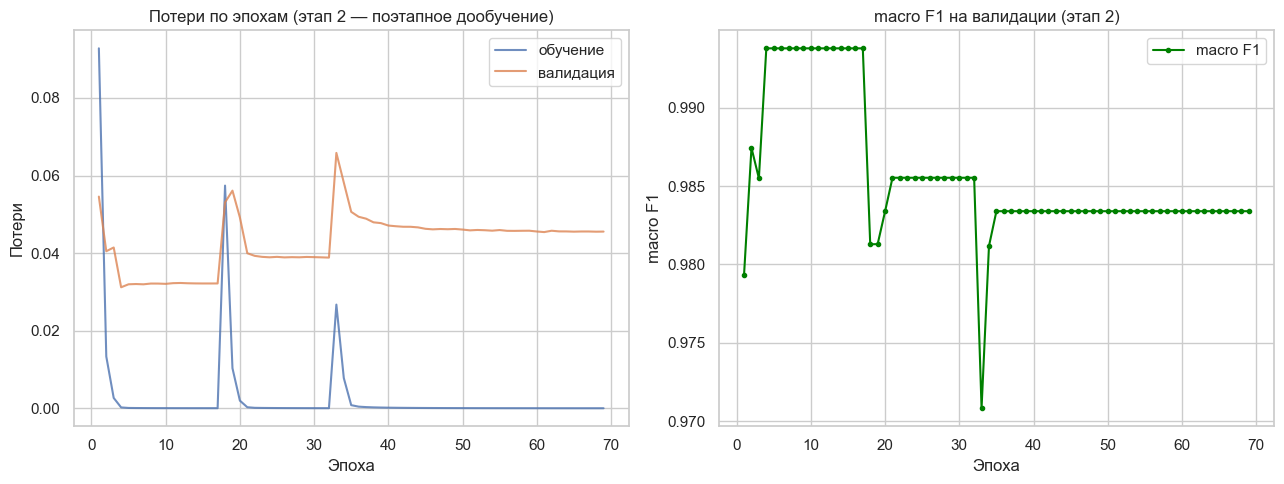

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(stage2_result['history']['val_loss']) + 1)

axes[0].plot(epochs_range, stage2_result['history']['train_loss'], label='обучение', alpha=0.8)
axes[0].plot(epochs_range, stage2_result['history']['val_loss'], label='валидация', alpha=0.8)
axes[0].set_title('Потери (этап 2)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери')
axes[0].legend()

axes[1].plot(epochs_range, stage2_result['history']['val_f1'], label='macro F1', color='green', marker='o', markersize=3)
axes[1].set_title('macro F1 (этап 2)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('macro F1')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'convnext_training_curves.png', dpi=100)
plt.show()

## Сохранение модели

Лучшие веса → `models/convnext_best.pth`.

In [9]:
best_model_path = MODELS_DIR / 'convnext_best.pth'
torch.save(stage2_result['best_state'], best_model_path)

print('ConvNeXt-Tiny, без аугментаций')
print(f'Точность на валидации: {stage2_result["best_acc"]:.4f}')
print(f'macro F1 на валидации: {stage2_result["best_f1"]:.4f}')
print(f'Модель сохранена: {best_model_path}')

ConvNeXt-Tiny (поэтапное дообучение, без аугментаций)
Точность на валидации: 0.9936
macro F1 на валидации: 0.9938
Модель сохранена: D:\building-type-classification\models\convnext_best.pth


## Метрики и матрица ошибок

In [10]:
final_model = build_convnext_tiny(num_classes=len(CLASSES), freeze_backbone=False).to(device)
final_model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
final_model.eval()

val_preds, val_labels, val_probs = collect_predictions(val_loader, final_model)

convnext_val_accuracy = float(np.mean(val_preds == val_labels))
convnext_val_macro_f1 = float(f1_score(val_labels, val_preds, average='macro', zero_division=0))

print(f'Точность на валидации: {convnext_val_accuracy:.4f}')
print(f'macro F1 на валидации: {convnext_val_macro_f1:.4f}')
print()
print('Отчёт классификации:')
print_classification_report_ru(val_labels, val_preds, CLASSES)

Точность на валидации: 0.9936
macro F1 на валидации: 0.9938

Отчёт классификации:
класс                   прециз.  полнота       F1 объектов
commercial                 0.98     1.00     0.99      116
industrial                 1.00     0.98     0.99      124
dense_residential          0.99     1.00     1.00      122
sparse_residential         1.00     1.00     1.00      109
точность                   0.99                        471
среднее macro              0.99     0.99     0.99      471
среднее взвеш.             0.99     0.99     0.99      471


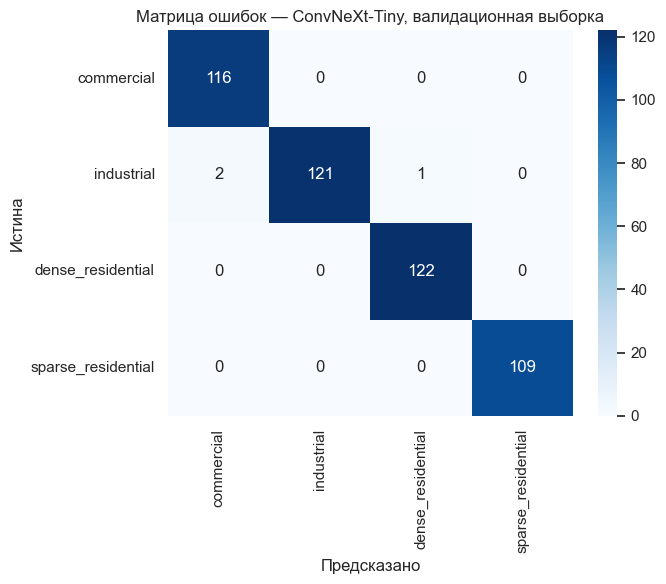

In [11]:
cm = confusion_matrix(val_labels, val_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истина')
ax.set_title('Матрица ошибок (val)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'convnext_confusion_matrix.png', dpi=100)
plt.show()

## Примеры

По 2 верных на класс + все ошибки на val.

In [ ]:
from PIL import Image

val_df = split_df[split_df['split'] == 'val'].reset_index(drop=True)


def show_prediction_examples(paths_df, labels, preds, probs, n_correct_per_class=2, seed=RANDOM_SEED):
    """Визуализация верных и ошибочных примеров."""
    rng = np.random.default_rng(seed)

    correct_indices = []
    for cls_idx, cls_name in enumerate(CLASSES):
        cls_correct = np.where((labels == cls_idx) & (preds == cls_idx))[0]
        if len(cls_correct) == 0:
            continue
        n_pick = min(n_correct_per_class, len(cls_correct))
        pick = rng.choice(cls_correct, size=n_pick, replace=False)
        correct_indices.extend(pick.tolist())

    error_indices = np.where(preds != labels)[0].tolist()

    def _plot_grid(indices, title, filename, cols=4):
        if not indices:
            print(f'{title}: нет примеров')
            return
        cols = min(cols, len(indices))
        rows = int(np.ceil(len(indices) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
        axes = np.atleast_1d(axes).ravel()
        for ax in axes[len(indices):]:
            ax.axis('off')
        for i, idx in enumerate(indices):
            img = Image.open(paths_df.iloc[idx]['path']).convert('RGB')
            true_cls = CLASSES[labels[idx]]
            pred_cls = CLASSES[preds[idx]]
            conf = float(probs[idx][preds[idx]])
            axes[i].imshow(img)
            caption = 'истина: ' + true_cls + '\nпредсказано: ' + pred_cls + f'\nуверенность: {conf:.2f}'
            axes[i].set_title(caption, fontsize=9)
            axes[i].axis('off')
        fig.suptitle(title, fontsize=12)
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / filename, dpi=100, bbox_inches='tight')
        plt.show()

    print(f'Правильных примеров: {len(correct_indices)} (до {n_correct_per_class} на класс)')
    _plot_grid(
        correct_indices,
        'Правильные предсказания (val)',
        'convnext_correct_examples.png',
    )

    print(f'Ошибочных примеров: {len(error_indices)}')
    _plot_grid(
        error_indices,
        'Ошибочные предсказания (val)',
        'convnext_error_examples.png',
        cols=4,
    )


show_prediction_examples(val_df, val_labels, val_preds, val_probs, n_correct_per_class=2)


## Выводы

1. **Качество:** macro F1 = 0.9938, точность = 0.9936 (471 img, 3 ошибки).

2. **Этап 1:** лучший LR — 1e-3 (macro F1 = 0.9728).

3. **Этап 2:** 69 эпох, лучший результат на подэтапе 1 (macro F1 = 0.9938). Дальнейшая разморозка не помогла.

4. **Классы:** `dense`/`sparse_residential` — F1 = 1.0; чаще путают `commercial` и `industrial`.

In [12]:
report_dict = classification_report(
    val_labels, val_preds, target_names=CLASSES, output_dict=True, zero_division=0
)
worst_class = min(CLASSES, key=lambda c: report_dict[c]['f1-score'])
best_class = max(CLASSES, key=lambda c: report_dict[c]['f1-score'])

history = stage2_result['history']
best_epoch_idx = int(np.argmax(history['val_f1']))
best_global_epoch = best_epoch_idx + 1
train_acc_at_best = history['train_acc'][best_epoch_idx]
val_acc_at_best = history['val_acc'][best_epoch_idx]
acc_gap = train_acc_at_best - val_acc_at_best
n_errors = int(np.sum(val_preds != val_labels))

print('=' * 60)
print('ИТОГИ — ConvNeXt-Tiny')
print('=' * 60)
print(f'Разбиение: обучение={len(train_ds)} валидация={len(val_ds)} тест={len(test_ds)} (70/15/15)')
print()
print('Этап 1 — подбор LR:')
for lr, res in lr_search_results.items():
    marker = ' <- лучший' if lr == best_lr else ''
    print(f'  LR={lr:.0e}: macro F1={res["best_val_f1"]:.4f}, эпох={res["epochs_run"]}{marker}')
print()
print('Этап 2 — дообучение:')
for sub in stage2_result['substage_results']:
    marker = ' <- лучший' if sub['substage'] == stage2_result['best_substage'] else ''
    print(
        f'  Подэтап {sub["substage"]}: {sub["epochs_run"]} эпох, '
        f'лучший macro F1={sub["best_f1"]:.4f} (эпоха {sub["best_epoch"]}){marker}'
    )
print(f'  Всего эпох: {stage2_result["epochs_run"]}/{MAX_EPOCHS}')
print()
print('Финальная модель:')
print(f'  Лучшая эпоха: {best_global_epoch} (подэтап {stage2_result["best_substage"]})')
print(f'  macro F1={convnext_val_macro_f1:.4f}, точность={convnext_val_accuracy:.4f}, ошибок={n_errors}')
print(f'  точность обучения={train_acc_at_best:.4f}, точность валидации={val_acc_at_best:.4f}, разрыв={acc_gap:.4f}')
print()
print('Классы:')
print(f'  лучший  — {best_class}: F1={report_dict[best_class]["f1-score"]:.4f}')
print(f'  слабый  — {worst_class}: F1={report_dict[worst_class]["f1-score"]:.4f}, '
      f'прециз.={report_dict[worst_class]["precision"]:.4f}, полнота={report_dict[worst_class]["recall"]:.4f}')
print()
print(f'Модель сохранена: {best_model_path}')

ИТОГИ ПЕРЕНОСА ОБУЧЕНИЯ — ConvNeXt-Tiny
Разбиение: обучение=2197 валидация=471 тест=471

Этап 1 — подбор скорости обучения (заморожена основа):
  LR=1e-03: macro F1=0.9728, эпох=15 <- лучший
  LR=3e-04: macro F1=0.9685, эпох=15
  LR=1e-04: macro F1=0.9542, эпох=15

Этап 2 — поэтапное дообучение:
  Подэтап 1: последние 2 стадии, LR=best_lr/10
  Подэтап 2: последние 4 стадии, LR=best_lr/20
  Подэтап 3: вся сеть, LR=best_lr/50
  Всего эпох: 69

Финальная модель ConvNeXt-Tiny:
  Точность на валидации: 0.9936
  macro F1 на валидации: 0.9938

Ранняя остановка: LOSS_EPS=0.0001, PATIENCE=7, MIN_EPOCHS=25, MAX_EPOCHS=100
Модель сохранена: D:\building-type-classification\models\convnext_best.pth
